In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt

print("✅ All imports successful")

✅ All imports successful


In [2]:
df = pd.read_csv("data/transactions_clean.csv", parse_dates=["ts"])
df = df.sort_values("ts").reset_index(drop=True)

def add_features(df):
    df = df.copy()
    df["log_amount"]           = np.log1p(df["amount"])
    df["avg_tx_amt_24h"]       = df["prev_24h_amt_card"] / (df["prev_24h_tx_count_card"] + 1e-3)
    df["velocity_ratio"]       = df["velocity_amt_1h"] / (df["avg_tx_amt_24h"] + 1e-3)
    df["amount_vs_24h_zscore"] = (df["amount"] - df["avg_tx_amt_24h"]) / (df["avg_tx_amt_24h"] + 1e-3)
    df["is_weekend"]           = df["dayofweek"].isin([5, 6]).astype(int)
    df["high_velocity_flag"]   = (df["prev_1h_tx_count_card"] > 3).astype(int)
    df["merchant_cat_rare"]    = 0
    return df

CUT   = int(len(df) * 0.80)
train = add_features(df.iloc[:CUT].copy())
valid = add_features(df.iloc[CUT:].copy())

NUM = ["amount","log_amount","prev_24h_tx_count_card","prev_24h_amt_card",
       "prev_1h_tx_count_card","velocity_amt_1h","avg_tx_amt_24h","velocity_ratio",
       "amount_vs_24h_zscore","hour","dayofweek",
       "is_international","is_night","is_weekend","merchant_cat_rare","high_velocity_flag"]
CAT = ["merchant_cat","city","country","device_type","channel"]
DROP = ["is_fraud","ts","tx_id","merchant_id_hash","card_id_hash"]

X_tr = train[NUM + CAT]; y_tr = train["is_fraud"]
X_va = valid[NUM + CAT]; y_va = valid["is_fraud"]

print(f"Train : {X_tr.shape} | Fraud: {y_tr.mean():.2%}")
print(f"Valid : {X_va.shape} | Fraud: {y_va.mean():.2%}")

Train : (40000, 21) | Fraud: 4.30%
Valid : (10000, 21) | Fraud: 4.22%


In [3]:
num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
cat_pipe = Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="unknown")),
                     ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer([
    ("num", num_pipe, NUM),
    ("cat", cat_pipe, CAT),
])
print("✅ Preprocessor ready")

✅ Preprocessor ready


In [4]:
FN_COST = 5000  # cost of missing a fraud (₹ loss)
FP_COST = 50    # cost of false block (customer friction)

def evaluate(name, proba, y, threshold=0.5):
    y_hat = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, y_hat).ravel()
    pr_auc  = average_precision_score(y, proba)
    roc_auc = roc_auc_score(y, proba)
    cost    = fn * FN_COST + fp * FP_COST

    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(f"  PR-AUC  : {pr_auc:.4f}   ← PRIMARY metric")
    print(f"  ROC-AUC : {roc_auc:.4f}")
    print(f"  TP={tp} | FP={fp} | FN={fn} | TN={tn}")
    print(f"  Cost    : ₹{cost:,.0f}")
    return pr_auc, roc_auc, proba

results = {}

print("⏳ Training LogisticRegression...")
logit = Pipeline([("pre", preprocessor),
                  ("clf", LogisticRegression(max_iter=500, class_weight="balanced", C=0.1))])
logit.fit(X_tr, y_tr)
p_lr = logit.predict_proba(X_va)[:,1]
pr1, roc1, _ = evaluate("Logistic Regression", p_lr, y_va)
results["LogisticRegression"] = {"pr_auc": pr1, "roc_auc": roc1, "proba": p_lr}

print("\n⏳ Training Random Forest (200 trees)...")
rf = Pipeline([("pre", preprocessor),
               ("clf", RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                               random_state=42, n_jobs=-1))])
rf.fit(X_tr, y_tr)
p_rf = rf.predict_proba(X_va)[:,1]
pr2, roc2, _ = evaluate("Random Forest", p_rf, y_va)
results["RandomForest"] = {"pr_auc": pr2, "roc_auc": roc2, "proba": p_rf}

⏳ Training LogisticRegression...

──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
  PR-AUC  : 0.9740   ← PRIMARY metric
  ROC-AUC : 0.9968
  TP=408 | FP=163 | FN=14 | TN=9415
  Cost    : ₹78,150

⏳ Training Random Forest (200 trees)...

──────────────────────────────────────────────────
  Random Forest
──────────────────────────────────────────────────
  PR-AUC  : 0.9616   ← PRIMARY metric
  ROC-AUC : 0.9923
  TP=355 | FP=14 | FN=67 | TN=9564
  Cost    : ₹335,700


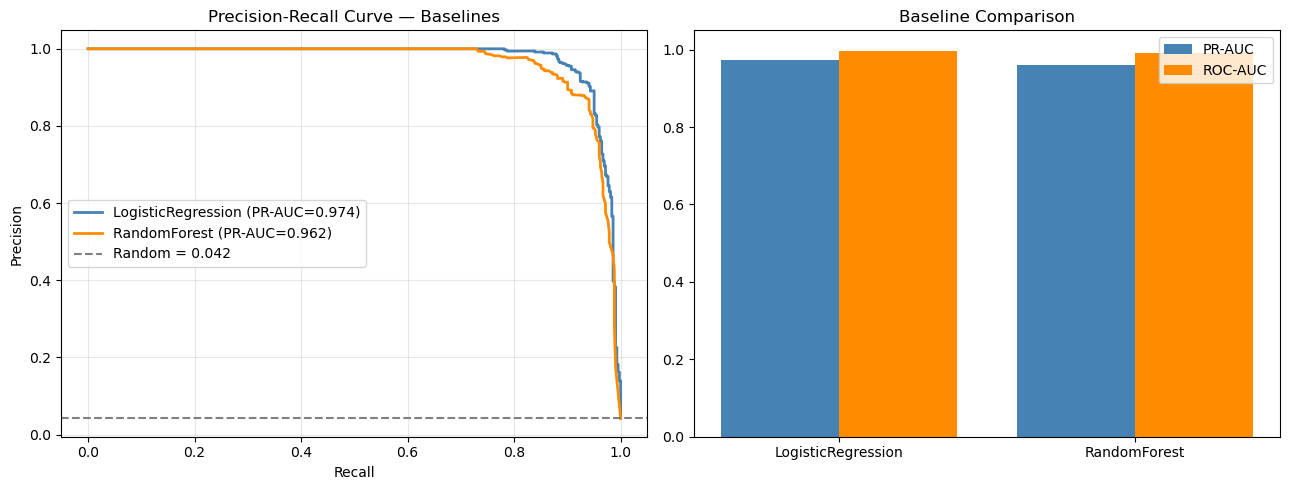


✅ Baselines done! Move to Notebook 4 → XGBoost Tuning


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = {"LogisticRegression": "steelblue", "RandomForest": "darkorange"}

for name, r in results.items():
    prec, rec, _ = precision_recall_curve(y_va, r["proba"])
    axes[0].plot(rec, prec, lw=2, color=colors[name],
                 label=f"{name} (PR-AUC={r['pr_auc']:.3f})")

axes[0].axhline(y_va.mean(), color="gray", linestyle="--", label=f"Random = {y_va.mean():.3f}")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-Recall Curve — Baselines")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Summary bar
names = list(results.keys())
pr_vals  = [results[n]["pr_auc"]  for n in names]
roc_vals = [results[n]["roc_auc"] for n in names]
x = np.arange(len(names))
axes[1].bar(x - 0.2, pr_vals,  0.4, label="PR-AUC",  color="steelblue")
axes[1].bar(x + 0.2, roc_vals, 0.4, label="ROC-AUC", color="darkorange")
axes[1].set_xticks(x); axes[1].set_xticklabels(names)
axes[1].set_title("Baseline Comparison"); axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.tight_layout(); plt.show()
print("\n✅ Baselines done! Move to Notebook 4 → XGBoost Tuning")